In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from utils.model import load_bird_list, load_birdnet_weights, import_dataset, sampling_strategy_evaluation_all_metrics
from utils.sampling import calculate_draw_probability, data_sampling
from sklearn.metrics import average_precision_score , roc_auc_score, f1_score


from scipy.signal import savgol_filter
import os
import pickle
import yaml

with open('config.yaml', 'r') as file: # load yaml config
    CONFIG = yaml.safe_load(file)

thresh_opt_cmAP = CONFIG['thresh_opt_cmAP']

In [2]:
bird_list_index, num_class = load_bird_list() # load WABAD species list

birdnet_weights, birdnet_bias = load_birdnet_weights(bird_list_index) # load birdnet last layer weights

x_train, y_train, x_val, y_val, x_test, y_test, y_scores_test, samples_df_train, birdnet_scores_train,  wabad_train_set_size, esc50_set_size = import_dataset(bird_list_index) # load train, val and test set

proba_vect = calculate_draw_probability(CONFIG["bird_sample_prop"], wabad_train_set_size, esc50_set_size )



Performance of the pre-trained model BirdNET

In [3]:
pretrained_class_AP = average_precision_score(y_test, y_scores_test , average=None, sample_weight=None)
pretrained_cmAP = average_precision_score(y_test, y_scores_test , average="macro", sample_weight=None)
pretrained_class_roc_auc= roc_auc_score(y_test, y_scores_test , average=None, sample_weight=None)
pretrained_macro_roc_auc = roc_auc_score(y_test, y_scores_test , average="macro", sample_weight=None)


metrics_row = pd.DataFrame({"parameter": ["Pre-trained"],
                           "cmAP": [pretrained_cmAP],
                            "macro_roc_auc": [pretrained_macro_roc_auc]})

per_class_metrics_row = pd.DataFrame({"parameter": ["Pre-trained"],
                                     "class_AP": [pretrained_class_AP],
                                    "class_roc_auc": [pretrained_macro_roc_auc]})


Model fine-tuned with 500 samples selected with the best sampling parameters (based on acoustic indices or BirdNET predictions) + random sampling

In [4]:

metrics_df = [metrics_row]
per_class_metrics_df = [per_class_metrics_row]

# number of iteration per condition
repetitions_num = 20

for sampling_parameter, threshold in thresh_opt_cmAP.items() :

    print(sampling_parameter)
    param_threshold = [sampling_parameter, threshold[0], threshold[1] ]

    for i in range(repetitions_num) :
        x_train_sampling, y_train_sampling, sampling_done, bird_proportion = data_sampling(x_train, y_train, CONFIG["sample_num"] ,  param_threshold , samples_df_train, proba_vect)

        if sampling_done == False:
            print("Error with sampling")
            break

        metrics_row , per_class_metrics_row = sampling_strategy_evaluation_all_metrics( x_train_sampling, y_train_sampling, x_val, y_val, x_test, y_test, num_class, birdnet_weights, birdnet_bias, display=False )

        metrics_row.insert(0, column="parameter", value=[sampling_parameter] )
        metrics_row.insert(1, column="bird_proportion", value=[bird_proportion] )

        per_class_metrics_row.insert(0, column="parameter", value=[sampling_parameter] )

        #metrics_df.insert(1, column="threshold", value=[threshold] )
        metrics_df.append(metrics_row)
        per_class_metrics_df.append(per_class_metrics_row)


metrics_df = pd.concat(metrics_df)
per_class_metrics_df = pd.concat(per_class_metrics_df)
metrics_df = metrics_df.groupby('parameter').mean().reset_index()

Random
TFSD
LEQf
NDSI
AEI
BI
MEANf
EPS_SKEW
EAS
nROI
ACI
BirdNETmax
Entropy_mean
Entropy_max


Model fine-tuned with the 500 samples with the higest influence score, calculated with reverse correlation

In [5]:
with open(os.path.join(CONFIG["results_path"], "predicted_influence_score.pkl") , "rb") as file:
   [cmAP_influence_score,  indices_train2, predicted_influence_train2] = pickle.load(file)

id_selection = np.argsort(cmAP_influence_score)[-CONFIG["sample_num"]:]


x_train_sampling = x_train[id_selection,:]
y_train_sampling = y_train[id_selection,:]
bird_proportion = np.sum(np.sum(y_train_sampling,axis=1) >= 1) / CONFIG["sample_num"]

metrics_row , per_class_metrics_row = sampling_strategy_evaluation_all_metrics( x_train_sampling, y_train_sampling, x_val, y_val, x_test, y_test, num_class, birdnet_weights, birdnet_bias, display=False )

metrics_row.insert(0, column="parameter", value=["top influence"] )
metrics_row.insert(1, column="bird_proportion", value=[bird_proportion] )

per_class_metrics_row.insert(0, column="parameter", value=["top influence"] )

metrics_df = pd.concat([metrics_df, metrics_row ])
per_class_metrics_df = pd.concat([per_class_metrics_df, per_class_metrics_row])




Model fine-tuned with 500 samples with the highest predicted influence score, calculated with the Ridge Regression model (on half of the train set)


In [6]:

id_selection = np.argsort(predicted_influence_train2)[-CONFIG["sample_num"]:]

x_train_sampling = x_train[indices_train2[id_selection],:]
y_train_sampling = y_train[indices_train2[id_selection],:]
bird_proportion = np.sum(np.sum(y_train_sampling,axis=1) >= 1) / CONFIG["sample_num"]

metrics_row , per_class_metrics_row = sampling_strategy_evaluation_all_metrics( x_train_sampling, y_train_sampling, x_val, y_val, x_test, y_test, num_class, birdnet_weights, birdnet_bias, display=False )


metrics_row.insert(0, column="parameter", value=["top predicted influence"] )
metrics_row.insert(1, column="bird_proportion", value=[bird_proportion] )

per_class_metrics_row.insert(0, column="parameter", value=["top predicted influence"] )


metrics_df = pd.concat([metrics_df, metrics_row ])
per_class_metrics_df = pd.concat([per_class_metrics_df, per_class_metrics_row])

In [7]:
metrics_df = metrics_df.sort_values(by=["cmAP"])
print( metrics_df)

                  parameter      cmAP  macro_roc_auc  bird_proportion
11              Pre-trained  0.366719       0.878582              NaN
12                   Random  0.372961       0.881573           0.0766
14                     nROI  0.375658       0.883654           0.0980
1                       AEI  0.378727       0.884642           0.2122
4                       EAS  0.379664       0.885280           0.1744
10                     NDSI  0.380489       0.886016           0.2496
2                        BI  0.380745       0.886399           0.4350
0                       ACI  0.381341       0.886481           0.1888
5                  EPS_SKEW  0.383616       0.887736           0.2505
9                     MEANf  0.385177       0.888796           0.2723
8                      LEQf  0.386455       0.889349           0.3464
13                     TFSD  0.394240       0.891948           0.8472
3                BirdNETmax  0.404096       0.897283           0.8324
7              Entro

Text(0.5, 0, 'cmAP')

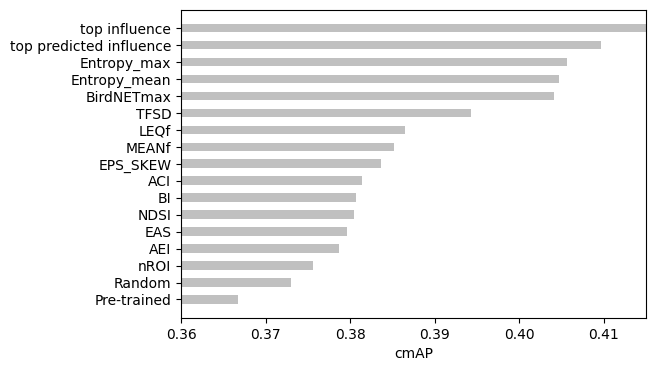

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), )
 
ax.barh(metrics_df["parameter"], metrics_df["cmAP"] , height = 0.5, color='silver')
ax.set_xlim([0.36, 0.415])
ax.set_xlabel("cmAP")


Text(0.5, 0, 'ROC AUC')

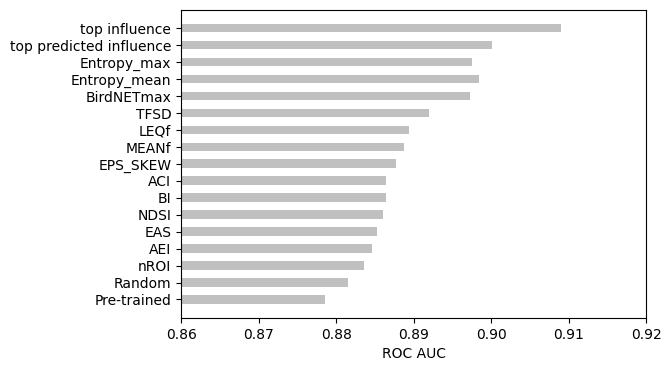

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), )
 
ax.barh(metrics_df["parameter"], metrics_df["macro_roc_auc"] , height = 0.5, color='silver')
ax.set_xlim([0.86 , 0.92])
ax.set_xlabel("ROC AUC")


In [10]:
#metrics_df = metrics_df.sort_values(by=["cmAP"], ascending=True)
#metrics_df.round(4).to_csv("metrics_df.csv")

In [11]:
influence_matrix = y_train.T  * cmAP_influence_score
class_mean_influence = []
for i in range(np.shape(influence_matrix)[0]):
    influence_vector = influence_matrix[i,:]
    non_nul_id = influence_vector != 0
    class_mean_influence.append(np.mean(influence_vector[non_nul_id]))
class_mean_influence = np.array(class_mean_influence)

In [12]:
parameter_selection =  ["Pre-trained", "Random", "TFSD", "Entropy_max", "BirdNETmax", "top predicted influence", "top influence"]
per_class_AP_df = per_class_metrics_df[["parameter", "class_AP" ]]

per_class_AP_df = per_class_AP_df[per_class_AP_df["parameter"].isin(parameter_selection)]

expanded_df = pd.DataFrame(per_class_AP_df['class_AP'].tolist())

expanded_df.columns = [species for species in CONFIG["bird_list_wabad"] ]

expanded_df.insert(0, column="parameter", value=per_class_AP_df["parameter"].tolist() )

expanded_df = expanded_df.groupby('parameter').mean().reset_index()

expanded_df = expanded_df.transpose().reset_index()


expanded_df.columns = expanded_df.iloc[0]
expanded_df = expanded_df.drop(expanded_df.index[0])
expanded_df = expanded_df.rename(columns={"parameter" : "species"})

(np.shape(y_test)[0] - esc50_set_size)

positive_rate = np.sum(y_train,axis=0)/(np.shape(y_train)[0] - esc50_set_size)/10

expanded_df.insert(1, column="positive rate", value=positive_rate )

expanded_df.insert(2, column="influence", value=class_mean_influence  )

expanded_df = expanded_df.apply(pd.to_numeric,errors='ignore' )

expanded_df = expanded_df.sort_values(by=["positive rate"], ascending=True)

/tmp/ipykernel_226870/1776260675.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  expanded_df = expanded_df.apply(pd.to_numeric,errors='ignore' )


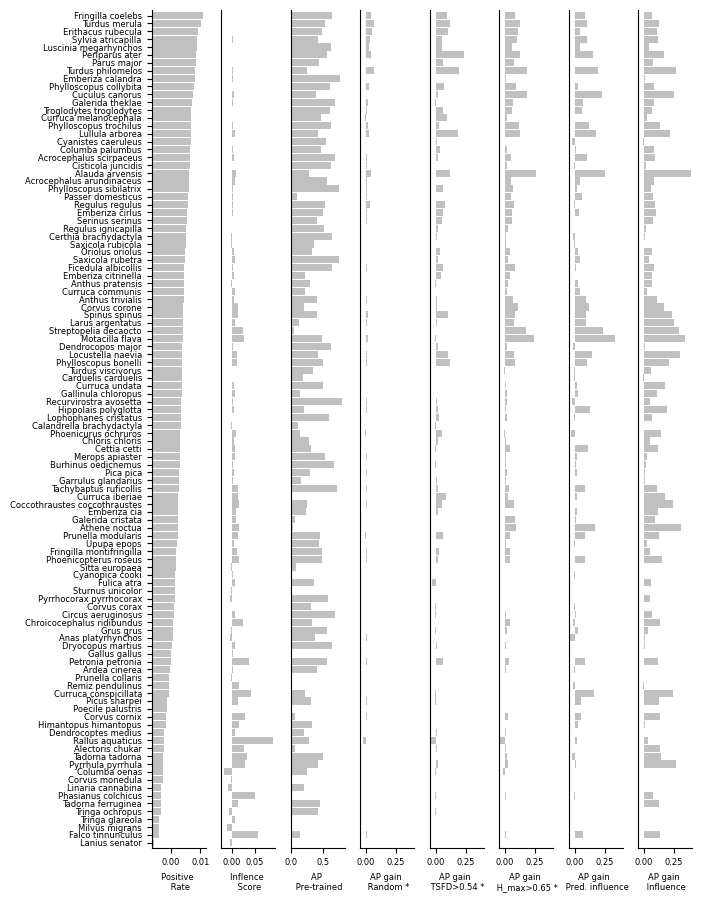

In [13]:
for i in expanded_df.columns[[3,4,5,6,7,8,9]] :
    expanded_df[f"diff_{i}"] = expanded_df[i] - expanded_df['Pre-trained']
    
plt.rcParams.update({'font.size': 6})
fig, ax = plt.subplots(1,8, figsize=(7, 9)) #, sharey=True)

expanded_df.plot.barh(x="species", y="positive rate", color="silver", width=0.9, ax = ax[0])


ax[0].set_xticks([])
ax[0].set_xscale('log')
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax[0].xaxis.set_major_formatter(formatter)
ax[0].set_xlabel("Positive \n Rate")
ax[0].legend()

expanded_df.plot.barh(x="species", y="influence", color="silver", width=0.9, ax = ax[1])
ax[1].set_xlabel("Inflence \n Score")

expanded_df.plot.barh(x="species", y="Pre-trained", color="silver", width=0.9, ax = ax[2])
ax[2].set_xlabel("AP \n Pre-trained")

expanded_df.plot.barh(x="species", y="diff_Random", color="silver", width=0.9, ax = ax[3])
ax[3].set_xlabel("AP gain \n Random *")


expanded_df.plot.barh(x="species", y="diff_TFSD", color="silver", width=0.9, ax = ax[4])
ax[4].set_xlabel("AP gain \n TSFD>0.54 *")


expanded_df.plot.barh(x="species", y="diff_Entropy_max", color="silver", width=0.9, ax = ax[5])
ax[5].set_xlabel("AP gain \n H_max>0.65 *")

expanded_df.plot.barh(x="species", y="diff_top predicted influence", color="silver", width=0.9, ax = ax[6])
ax[6].set_xlabel("AP gain \n Pred. influence")

expanded_df.plot.barh(x="species", y="diff_top influence", color="silver", width=0.9, ax = ax[7])
ax[7].set_xlabel("AP gain \n Influence")



for i in range(8):
    ax[i].legend().set_visible(False)
    ax[i].set_ylabel("")
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

for i in range(1,8):
    ax[i].set_yticks([])

for i in range(3,8):
    ax[i].set_xlim([-0.05, 0.40])
    


plt.tight_layout()

#plt.savefig("by_class_analysis.pdf", format="pdf", bbox_inches="tight")
